In [228]:
import pandas as pd

# If the file is in the same folder as your notebook
df = pd.read_csv('F:\Data Science & AI\London\london_air_quality_2010_2023_top5_sites.csv')

In [150]:
from statsmodels.tsa.seasonal import seasonal_decompose, DecomposeResult
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, mean_absolute_percentage_error
from statsmodels.tsa.stattools import adfuller, acf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.ar_model import AutoReg, AutoRegResultsWrapper
from typing import Any
from matplotlib.figure import Figure
from matplotlib.axes._axes import Axes

In [33]:
earliest_date: str = df["datetime"].min()
latest_date: str = df["datetime"].max()

print(f"Earliest date: {earliest_date}")
print(f"Latest date: {latest_date}")

Earliest date: 2010-01-01 00:00:00
Latest date: 2023-12-30 23:00:00


In [38]:
Camden_Bloomsbury_no2 = df[df['SiteName'] == 'Camden - Bloomsbury']['no2_level']

In [39]:
Camden_Bloomsbury_no2

datetime
2010-01-01 00:00:00    54.8
2010-01-01 01:00:00    51.0
2010-01-01 02:00:00    49.2
2010-01-01 03:00:00    43.0
2010-01-01 04:00:00    39.7
                       ... 
2023-08-20 20:00:00    11.7
2023-08-20 21:00:00    12.0
2023-08-20 22:00:00    10.5
2023-08-20 23:00:00    10.5
2023-08-21 00:00:00     9.6
Name: no2_level, Length: 117954, dtype: float64

In [36]:
df['datetime'] = pd.to_datetime(df['datetime'])

In [37]:
df.index = pd.to_datetime(df['datetime'])

In [8]:
df

,datetime,LocalAuthorityCode,LocalAuthorityName,SiteCode,SiteName,SiteType,Latitude,Longitude,co_level,no2_level,o3_level,pm10_level,pm25_level,so2_level
datetime,,,,,,,,,,,,,,
2010-01-01 00:00:00,2010-01-01 00:00:00,6,Camden,BL0,Camden - Bloomsbury,Urban Background,51.522287,-0.125848,NaN,54.8,20.6,16.0,16.0,1.8
2010-01-01 01:00:00,2010-01-01 01:00:00,6,Camden,BL0,Camden - Bloomsbury,Urban Background,51.522287,-0.125848,0.2,51.0,21.3,13.0,15.0,0.0
2010-01-01 02:00:00,2010-01-01 02:00:00,6,Camden,BL0,Camden - Bloomsbury,Urban Background,51.522287,-0.125848,0.2,49.2,23.4,10.0,9.0,0.0
2010-01-01 03:00:00,2010-01-01 03:00:00,6,Camden,BL0,Camden - Bloomsbury,Urban Background,51.522287,-0.125848,0.1,43.0,27.4,10.0,9.0,0.0
2010-01-01 04:00:00,2010-01-01 04:00:00,6,Camden,BL0,Camden - Bloomsbury,Urban Background,51.522287,-0.125848,0.1,39.7,29.4,9.0,8.0,0.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-28 06:00:00,2023-12-28 06:00:00,27,Richmond,RI2,Richmond Upon Thames - Barnes Wetlands,Suburban,51.476168,-0.230427,NaN,NaN,NaN,16.6,NaN,NaN
2023-12-28 07:00:00,2023-12-28 07:00:00,27,Richmond,RI2,Richmond Upon Thames - Barnes Wetlands,Suburban,51.476168,-0.230427,NaN,NaN,NaN,21.1,NaN,NaN
2023-12-28 08:00:00,2023-12-28 08:00:00,27,Richmond,RI2,Richmond Upon Thames - Barnes Wetlands,Suburban,51.476168,-0.230427,NaN,NaN,NaN,28.3,NaN,NaN


In [9]:
no2_daily= df['no2_level'].resample('D').mean()

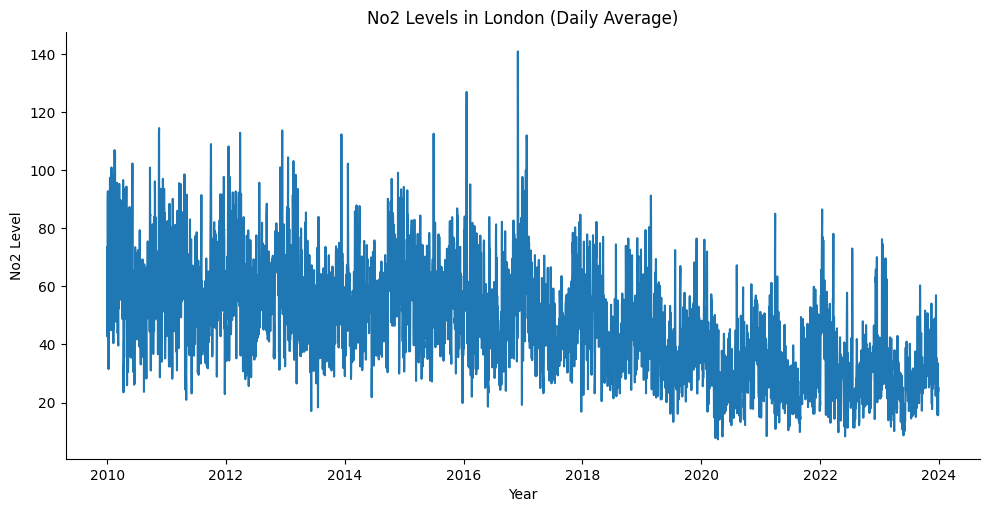

In [10]:
(
  sns.relplot(
      kind="line",
      data=no2_daily,
      aspect=2,
      legend=False
  ).set(
      title="No2 Levels in London (Daily Average)",
      xlabel="Year",
      ylabel="No2 Level"
  )
);

In [11]:
no2_daily.index = pd.to_datetime(no2_daily.index)

In [12]:
no2_daily = no2_daily.reindex(
    pd.date_range(no2_daily.index.min(), no2_daily.index.max(), freq="D")
)

In [13]:
no2_daily = no2_daily.ffill()

In [249]:
no2_weekly = no2_daily.asfreq("W")

In [247]:
no2_weekly

2010-01-01    54.434167
2010-01-02    73.595833
2010-01-03    42.633333
2010-01-04    89.274167
2010-01-05    92.711765
                ...    
2023-12-26    33.535714
2023-12-27    20.136111
2023-12-28    15.618056
2023-12-29    25.347222
2023-12-30    24.095833
Freq: D, Name: no2_level, Length: 5112, dtype: float64

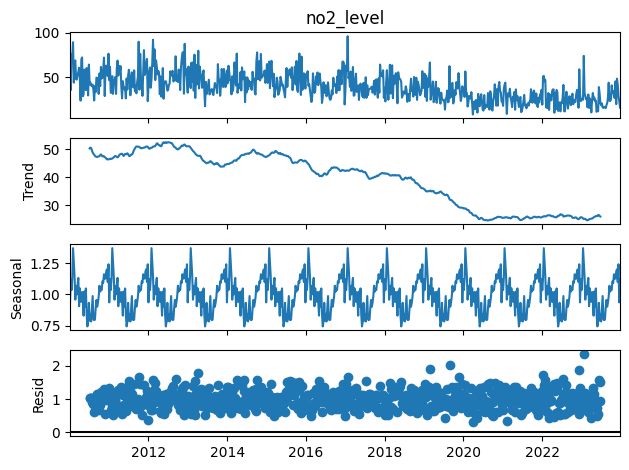

In [250]:
decomposition: DecomposeResult = seasonal_decompose(
    no2_weekly,
    model="multiplicative"
)

decomposition.plot();

In [16]:
def plot_component(
  data_to_plot: pd.Series,
  colour: str,
  title: str
) -> sns.FacetGrid:

  g: sns.FacetGrid = sns.relplot(
      kind="line",
      data=data_to_plot,
      color=colour,
      aspect=2
  ).set(
      title=title
  )

  return g

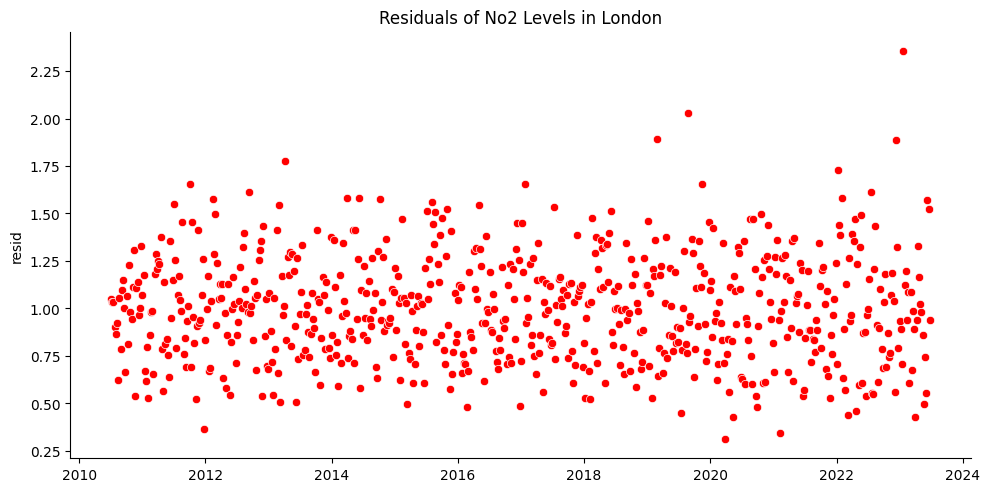

In [17]:
(
    sns.relplot(
        kind="scatter",
        data=decomposition.resid,
        color="red",
        aspect=2
    ).set(
        title="Residuals of No2 Levels in London"
    )
);

In [57]:
Camden_Bloomsbury_no2 = Camden_Bloomsbury_no2.asfreq("M")

C:\Users\furin\AppData\Local\Temp\ipykernel_16728\1478239735.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  Camden_Bloomsbury_no2 = Camden_Bloomsbury_no2.asfreq("M")


In [60]:
Camden_Bloomsbury_no2.isnull().sum()

np.int64(4767)

In [61]:
Camden_Bloomsbury_no2.ffill(inplace= True)

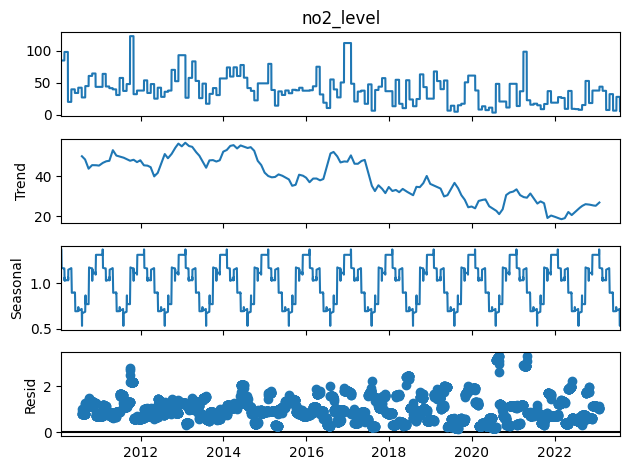

In [62]:
# Ensure the index is a DatetimeIndex
Camden_Bloomsbury_no2.index = pd.to_datetime(Camden_Bloomsbury_no2.index)

# Set the frequency if it's not already set
Camden_Bloomsbury_no2 = Camden_Bloomsbury_no2.asfreq('D')  # or 'M' for monthly data

# Perform decomposition with specified period if necessary
decomposition = seasonal_decompose(
    Camden_Bloomsbury_no2,
    model="multiplicative",
    period=365  # Adjust this to match your data's cycle
)

decomposition.plot();


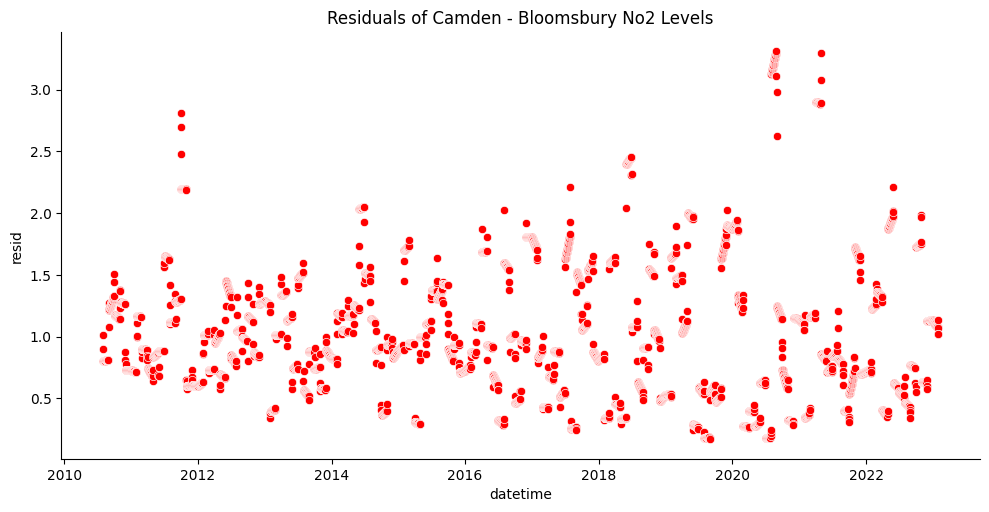

In [63]:
(
    sns.relplot(
        kind="scatter",
        data=decomposition.resid,
        color="red",
        aspect=2
    ).set(
        title="Residuals of Camden - Bloomsbury No2 Levels"
    )
);

In [64]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(Camden_Bloomsbury_no2)

print("ADF statistic:", result[0])
print("p-value:", result[1])

ADF statistic: -6.407879469971441
p-value: 1.923059935303849e-08


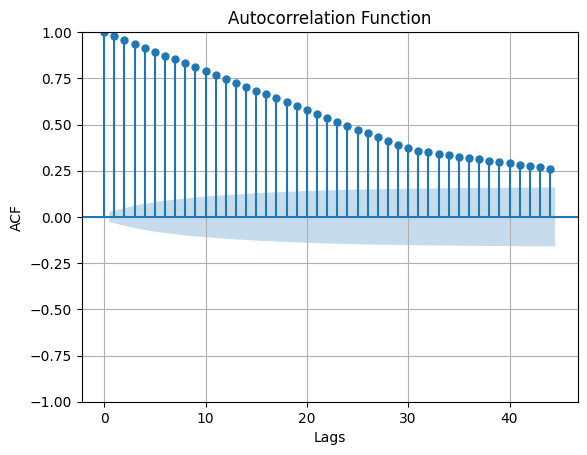

In [65]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf


# Plot the ACF
plot_acf(Camden_Bloomsbury_no2, lags=44)  # You can adjust the number of lags
plt.title('Autocorrelation Function')
plt.xlabel('Lags')
plt.ylabel('ACF')
plt.grid(True)
plt.show()


In [66]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, mean_absolute_percentage_error
from statsmodels.tsa.seasonal import seasonal_decompose, DecomposeResult

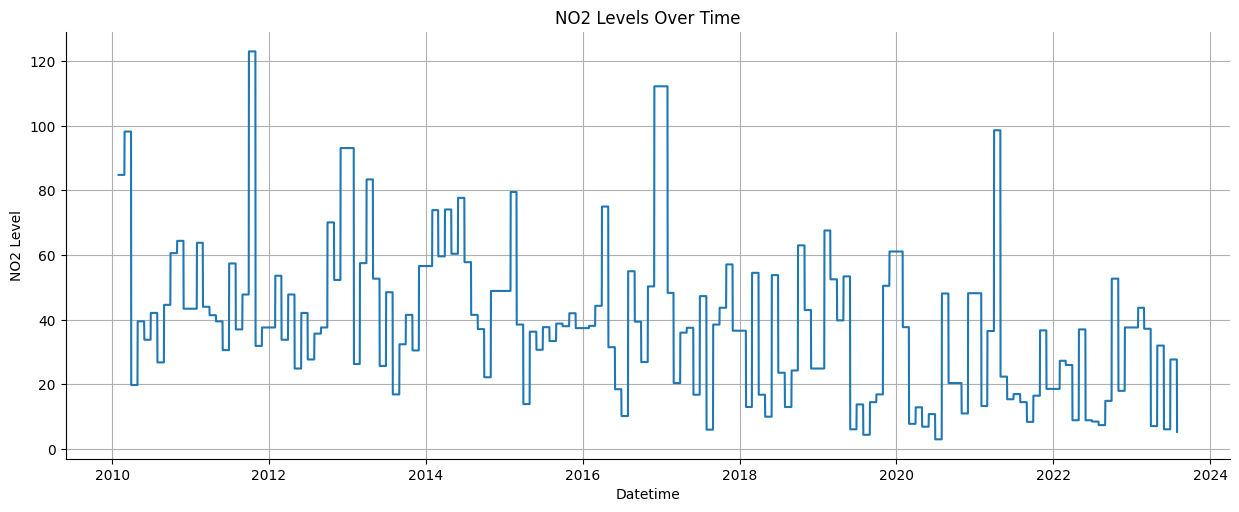

In [67]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming Camden_Bloomsbury_no2 is a pandas Series with a DatetimeIndex
# First, convert the Series to a DataFrame
Camden_Bloomsbury_no2_df = Camden_Bloomsbury_no2.reset_index()
Camden_Bloomsbury_no2_df.columns = ['datetime', 'no2_level']  # Rename columns appropriately

# Now use sns.relplot
sns.relplot(data=Camden_Bloomsbury_no2_df, x='datetime', y='no2_level', kind='line', aspect = 2.5)

plt.title('NO2 Levels Over Time')
plt.xlabel('Datetime')
plt.ylabel('NO2 Level')
plt.grid(True)
plt.show()


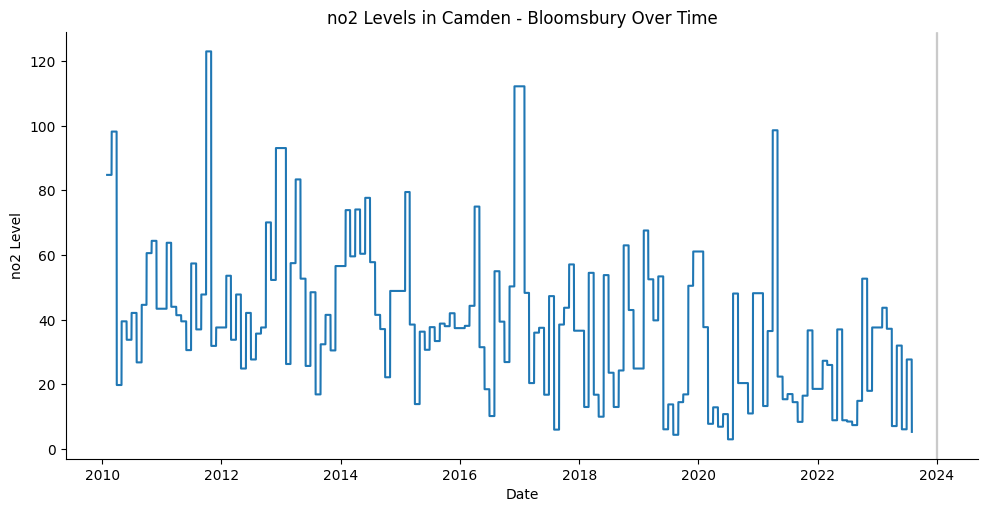

In [68]:
# Plot the data
g: sns.FacetGrid = sns.relplot(kind="line",
                               data=Camden_Bloomsbury_no2,
                               aspect=2,
                               legend=False)

# Customise labels and title
g.set_axis_labels("Date", "no2 Level")
g.set(title="no2 Levels in Camden - Bloomsbury Over Time")

# Highlight the last 7 days
last_prediction_date: pd.Timestamp = df.index.max()
first_prediction_date: pd.Timestamp = last_prediction_date - pd.Timedelta(days=6)
g.ax.axvspan(first_prediction_date,
             last_prediction_date,
             color="grey",
             alpha=0.3);

In [72]:
Camden_Bloomsbury_no2

datetime
2010-01-31    84.8
2010-02-01    84.8
2010-02-02    84.8
2010-02-03    84.8
2010-02-04    84.8
              ... 
2023-07-27    27.7
2023-07-28    27.7
2023-07-29    27.7
2023-07-30    27.7
2023-07-31     5.3
Freq: D, Name: no2_level, Length: 4930, dtype: float64

In [ ]:
no2_daily2= df['no2_level'].resample('D').mean()

In [114]:
no2_daily2

datetime
2010-01-01    63.785714
2010-01-02    63.275000
2010-01-03    51.379167
2010-01-04    69.300000
2010-01-05    62.035556
                ...    
2017-01-07    44.383333
2017-01-08    49.904167
2017-01-09    37.721739
2017-01-10    47.041667
2017-01-11    28.807143
Freq: D, Name: no2_level, Length: 2568, dtype: float64

In [117]:
import pandas as pd
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf
from typing import Any


result: Any = adfuller(df["no2_level"])

# Print the ADF statistic and the p-value
print("ADF Statistic: %f" % result[0])
print("p-value: %f" % result[1])

# Print the critical values for different confidence levels
print("Critical Values:")
for key, value in result[4].items():
    print(f"\t{key}: {value:.3f}")

ADF Statistic: -18.592696
p-value: 0.000000
Critical Values:
	1%: -3.430
	5%: -2.862
	10%: -2.567


In [78]:
# Differencing
df: pd.DataFrame
df['no2_level_diff'] = df['no2_level'].diff()
df.head()

,datetime,LocalAuthorityCode,LocalAuthorityName,SiteCode,SiteName,SiteType,Latitude,Longitude,co_level,no2_level,o3_level,pm10_level,pm25_level,so2_level,no2_level_diff
datetime,,,,,,,,,,,,,,,
2010-01-01 00:00:00,2010-01-01 00:00:00,6,Camden,BL0,Camden - Bloomsbury,Urban Background,51.522287,-0.125848,NaN,54.8,20.6,16.0,16.0,1.8,NaN
2010-01-01 01:00:00,2010-01-01 01:00:00,6,Camden,BL0,Camden - Bloomsbury,Urban Background,51.522287,-0.125848,0.2,51.0,21.3,13.0,15.0,0.0,-3.8
2010-01-01 02:00:00,2010-01-01 02:00:00,6,Camden,BL0,Camden - Bloomsbury,Urban Background,51.522287,-0.125848,0.2,49.2,23.4,10.0,9.0,0.0,-1.8
2010-01-01 03:00:00,2010-01-01 03:00:00,6,Camden,BL0,Camden - Bloomsbury,Urban Background,51.522287,-0.125848,0.1,43.0,27.4,10.0,9.0,0.0,-6.2
2010-01-01 04:00:00,2010-01-01 04:00:00,6,Camden,BL0,Camden - Bloomsbury,Urban Background,51.522287,-0.125848,0.1,39.7,29.4,9.0,8.0,0.7,-3.3


In [79]:
df: pd.DataFrame = df.dropna()
df.head()

,datetime,LocalAuthorityCode,LocalAuthorityName,SiteCode,SiteName,SiteType,Latitude,Longitude,co_level,no2_level,o3_level,pm10_level,pm25_level,so2_level,no2_level_diff
datetime,,,,,,,,,,,,,,,
2010-01-01 01:00:00,2010-01-01 01:00:00,6,Camden,BL0,Camden - Bloomsbury,Urban Background,51.522287,-0.125848,0.2,51.0,21.3,13.0,15.0,0.0,-3.8
2010-01-01 02:00:00,2010-01-01 02:00:00,6,Camden,BL0,Camden - Bloomsbury,Urban Background,51.522287,-0.125848,0.2,49.2,23.4,10.0,9.0,0.0,-1.8
2010-01-01 03:00:00,2010-01-01 03:00:00,6,Camden,BL0,Camden - Bloomsbury,Urban Background,51.522287,-0.125848,0.1,43.0,27.4,10.0,9.0,0.0,-6.2
2010-01-01 04:00:00,2010-01-01 04:00:00,6,Camden,BL0,Camden - Bloomsbury,Urban Background,51.522287,-0.125848,0.1,39.7,29.4,9.0,8.0,0.7,-3.3
2010-01-01 05:00:00,2010-01-01 05:00:00,6,Camden,BL0,Camden - Bloomsbury,Urban Background,51.522287,-0.125848,0.1,44.5,28.4,9.0,7.0,0.0,4.8


In [119]:
# Perform the ADF test on the differenced data
result = adfuller(df['no2_level_diff'])

# Print the ADF statistic and the p-value after differencing
print('ADF Statistic after differencing: %f' % result[0])
print('p-value after differencing: %f' % result[1])

# Print the critical values after differencing
print('Critical Values after differencing:')
for key, value in result[4].items():
    print(f"\t{key}: {value:.3f}")

ADF Statistic after differencing: -45.377196
p-value after differencing: 0.000000
Critical Values after differencing:
	1%: -3.430
	5%: -2.862
	10%: -2.567


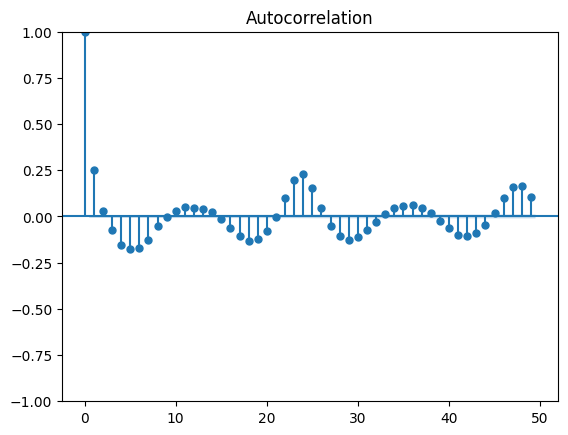

In [81]:
plot_acf(df['no2_level_diff']);

In [89]:
# 90% train, 10% test
df: pd.DataFrame
train: pd.DataFrame = df[:int(len(df)*0.9)]
test: pd.DataFrame = df[int(len(df)*0.9):]

print("Train length:", len(train))
print("Test length:", len(test))

Train length: 63730
Test length: 7082


In [90]:
def moving_average_forecast(
    train_series: pd.Series,
    test_series: pd.Series,
    window_size: int
) -> list[float]:
    # Convert the training series into a list to maintain a history of observations
    history = list(train_series)
    # Initialise an empty list to store the forecasted values
    predictions: list[float] = []

    # Loop over each time point in the test series
    for t in range(len(test_series)):

        # Calculate the average of the last 'window_size' observations
        window = history[-window_size:]
        yhat = sum(window) / window_size

        # Append the forecasted value to the predictions list
        predictions.append(yhat)

        # Simulate new data rolling in by adding the next test value to 'history'
        history.append(test_series.iloc[t])

    # Return the list of forecasted values
    return predictions

In [91]:
window_size: int = 5

predictions_ma5: list[float] = moving_average_forecast(train['no2_level'],
                                                       test['no2_level'],
                                                       window_size)

<Axes: xlabel='datetime', ylabel='no2_level'>

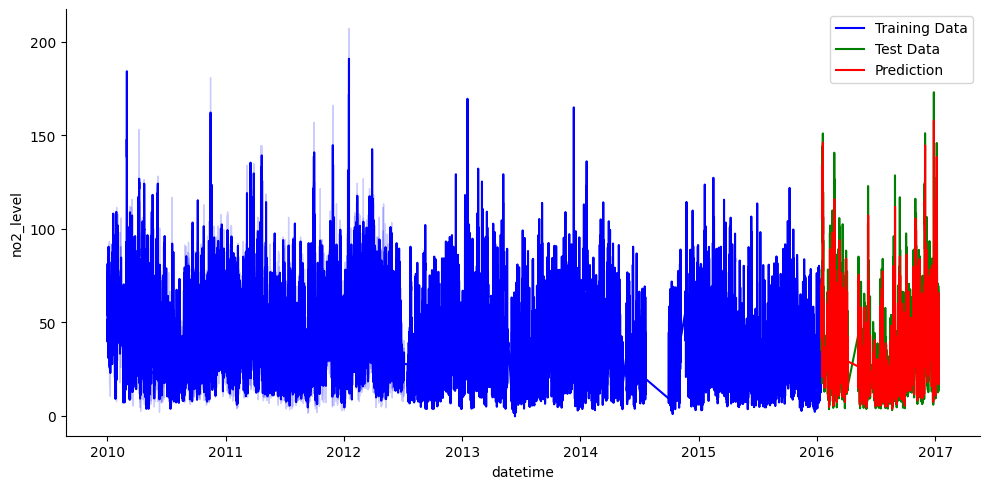

In [92]:
# Plot the Train Data
g: sns.FacetGrid = sns.relplot(kind='line',
                               data=train,
                               x=train.index,
                               y='no2_level',
                               color='blue',
                               label='Training Data',
                               aspect=2)

# Plot the Test Data on the same axis
sns.lineplot(data=test,
             x=test.index,
             y='no2_level',
             color='green',
             label='Test Data',
             ax=g.ax)

# Plot the Predictions on the same axis
sns.lineplot(data=test,
             x=test.index,
             y=predictions_ma5,
             color='red',
             label='Prediction',
             ax=g.ax)



In [93]:
# Creating a function as we'll use this code again

def plot_predictions(predictions: list[float], window_size: int) -> None:
  # Plot the Test Data
  g: sns.FacetGrid = sns.relplot(kind='line',
                                 data=test,
                                 x=test.index,
                                 y='no2_level',
                                 color='green',
                                 label='Test Data',
                                 aspect=2)

  # Plot the Predictions on the same axis
  sns.lineplot(data=test,
               x=test.index,
               y=predictions,
               color='red',
               label='Prediction',
               ax=g.ax)
    

In [94]:
def evaluate_forecast(
    predictions: list[float],
    window_size: int
) -> dict[str, float]:

  mae = mean_absolute_error(test['no2_level'],
                            predictions)

  rmse = root_mean_squared_error(test['no2_level'],
                                 predictions)

  mape = mean_absolute_percentage_error(test['no2_level'],
                                        predictions)

  print(f"""Evaluation Metrics for Moving Average Forecast (Window Size = {window_size}):
  \t Mean Absolute Error (MAE): {mae:.2f}
  \t Root Mean Squared Error (RMSE): {rmse:.2f}
  \t Mean Absolute Percentage Error (MAPE): {mape * 100:.2f}%""")

  return {
      'mae': mae,
      'rmse': rmse,
      'mape': mape
  }

In [95]:
ma5_evaluation: dict[str, float | int] = evaluate_forecast(predictions_ma5, window_size)

Evaluation Metrics for Moving Average Forecast (Window Size = 5):
  	 Mean Absolute Error (MAE): 9.74
  	 Root Mean Squared Error (RMSE): 13.33
  	 Mean Absolute Percentage Error (MAPE): 33.65%


In [96]:
results_data: dict[str, str | float] = {
    'Model': 'Moving Average (5)',
    'MAE': ma5_evaluation["mae"],
    'RMSE': ma5_evaluation["rmse"],
    'MAPE': ma5_evaluation["mape"]
}

results_df: pd.DataFrame = pd.DataFrame([results_data])

results_df

,Model,MAE,RMSE,MAPE
0,Moving Average (5),9.739209,13.332965,0.336527


In [97]:
window_size: int = 10

predictions_ma10: list[float] = moving_average_forecast(train['no2_level'],
                                                        test['no2_level'],
                                                        window_size)

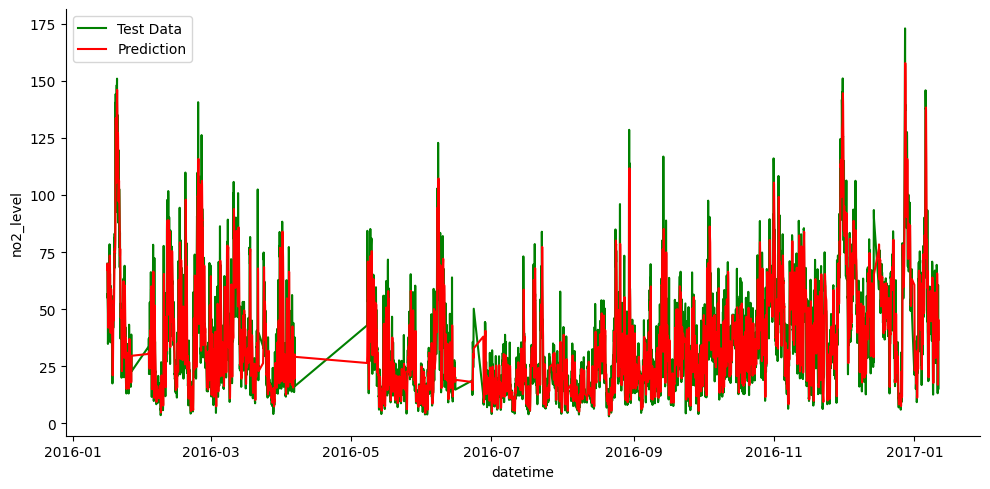

In [127]:
plot_predictions(predictions_ma5, 5)

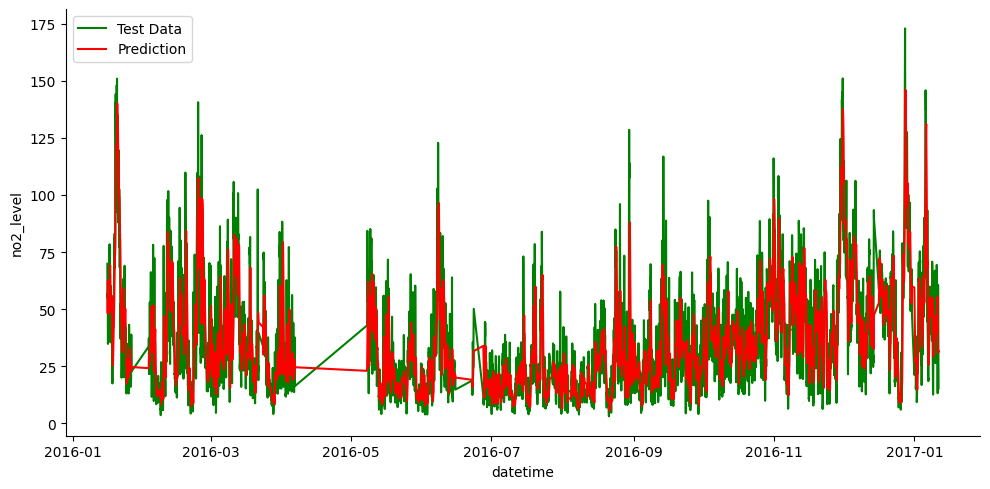

In [98]:
plot_predictions(predictions_ma10, 10)

In [102]:
ma10_evaluation: dict[str, float | int] = evaluate_forecast(predictions_ma10, window_size)

Evaluation Metrics for Moving Average Forecast (Window Size = 10):
  	 Mean Absolute Error (MAE): 11.22
  	 Root Mean Squared Error (RMSE): 15.15
  	 Mean Absolute Percentage Error (MAPE): 40.88%


In [103]:
results_data: dict[str, str | float] = {
    'Model': 'Moving Average (10)',
    'MAE': ma10_evaluation["mae"],
    'RMSE': ma10_evaluation["rmse"],
    'MAPE': ma10_evaluation["mape"]
}

results_df: pd.DataFrame = pd.DataFrame([results_data])

results_df

,Model,MAE,RMSE,MAPE
0,Moving Average (10),11.219751,15.152677,0.408846


In [151]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, root_mean_squared_error, mean_absolute_percentage_error
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA, ARIMAResults
from statsmodels.tsa.statespace.sarimax import SARIMAX, SARIMAXResults

from typing import Any
from matplotlib.figure import Figure
from matplotlib.axes import Axes

In [134]:
df = df.asfreq('D')

In [129]:
d: int = 1  # since we know from our previous notebooks that the data should be differenced once
p: int = 0  # PACF cuts off after lag 0
q: int = 0  # ACF cuts off after lag 0

In [146]:
df = df.dropna()

In [161]:
def plot_acf_pacf() -> None:
    fig: Figure
    axes: np.ndarray[Axes]

    fig, axes = plt.subplots(2, 1, figsize=(8, 12))

    plot_acf(diff_df["no2_level_diff"],
            lags=40,
            ax=axes[0])

    plot_pacf(diff_df["no2_level_diff"],
              lags=40,
              ax=axes[1])

    axes[0].set_title("ACF Plot")
    axes[1].set_title("PACF Plot")

    plt.show()

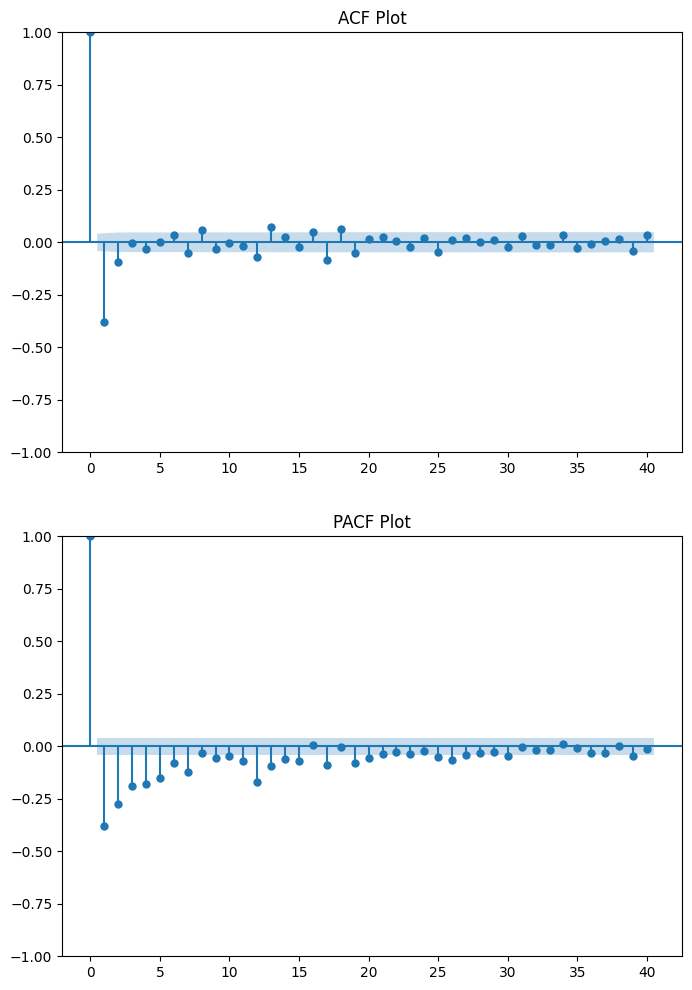

In [162]:
plot_acf_pacf()

In [163]:
arima_df = df[['no2_level', 'no2_level_diff']]

In [ ]:
# Split data into train and test sets
train_size = int(len(df) * 0.9)

train: pd.DataFrame = df.iloc[:train_size]
test: pd.DataFrame = df.iloc[train_size:]

print(f"Train size: {len(train)}")
print(f"Test size: {len(test)}")

Train size: 2054
Test size: 229


In [201]:
# Define the model
arima_model: ARIMA = ARIMA(train['no2_level_diff'],
                           order=(p, d, q))  # remember, we set p, d, & q earlier with the ACF and PACF plots

# Fit the model
arima_fit: ARIMAResults = arima_model.fit()

f:\Data Science & AI\London\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
f:\Data Science & AI\London\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
f:\Data Science & AI\London\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [202]:
arima_forecast: pd.Series = arima_fit.forecast(steps=len(test))
arima_predictions: pd.DataFrame = pd.DataFrame(arima_forecast, index=test.index)

f:\Data Science & AI\London\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
f:\Data Science & AI\London\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [203]:
arima_predictions

,predicted_mean
datetime,
2016-03-29 01:00:00,NaN
2016-03-30 01:00:00,NaN
2016-03-31 01:00:00,NaN
2016-04-01 01:00:00,NaN
2016-04-02 01:00:00,NaN
...,...
2017-01-06 01:00:00,NaN
2017-01-07 01:00:00,NaN
2017-01-08 01:00:00,NaN


In [ ]:
arima_predictions# we'll use this code again later, so let's make it a function to save repetition
def plot_forecasts(
    test: pd.DataFrame,
    predictions: pd.DataFrame,
    title: str
) -> None:

  g: sns.FacetGrid = sns.relplot(kind='line',
                                 data=test,
                                 x=test.index,
                                 y='no2_level',
                                 color='green',
                                 label='Test Data',
                                 aspect=1.5)

  # Plot the Predictions on the same axis
  sns.lineplot(data=predictions,
               x=predictions.index,
               y='predicted_mean',
               color='red',
               label='Prediction',
               ax=g.ax)


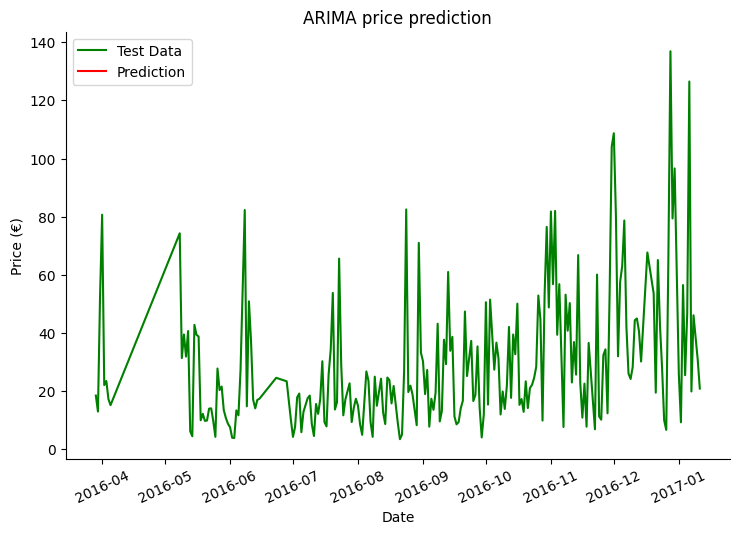

In [196]:
plot_forecasts(test, arima_predictions, "ARIMA price prediction")

In [197]:
# we'll use this code again later, so let's make it a function to save on repetition
def evaluate_model(
    test: pd.DataFrame,
    predictions: pd.DataFrame,
    model_name: str = "Model"
) -> dict[str, float]:

    mae: float = mean_absolute_error(test['no2_level'], predictions['predicted_mean'])
    rmse: float = root_mean_squared_error(test['no2_level'], predictions['predicted_mean'])
    mape: float = mean_absolute_percentage_error(test['no2_level'], predictions['predicted_mean'])

    print(f"Evaluation Metrics for {model_name} Forecast:")
    print(f"\t Mean Absolute Error (MAE): {mae:.2f}")
    print(f"\t Root Mean Squared Error (RMSE): {rmse:.2f}")
    print(f"\t Mean Absolute Percentage Error (MAPE): {mape * 100:.2f}%")

    return {"MAE": mae, "RMSE": rmse, "MAPE": mape}

In [208]:
import pandas as pd
import numpy as np
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 1) Make sure your series is indexed correctly
df = df.sort_index()
df = df.asfreq("D")  # or your true frequency

# 2) Create differenced series
df["no2_level_diff"] = df["no2_level"].diff()

# Drop first NA introduced by differencing
df = df.dropna(subset=["no2_level_diff"])

# 3) Train–test split
train_size = int(len(df) * 0.9)
train = df.iloc[:train_size]
test = df.iloc[train_size:]

print(len(train), len(test))

# 4) Fit ARIMA on the differenced series
model = ARIMA(train["no2_level_diff"], order=(p, d, q))
fit = model.fit()

# 5) Forecast differenced values
diff_forecast = fit.forecast(steps=len(test))

# 6) Convert differenced forecast back to level forecast
# start from last observed level value
last_train_value = train["no2_level"].iloc[-1]

level_forecast = last_train_value + diff_forecast.cumsum()

# 7) Build prediction dataframe (now has predicted_mean)
arima_predictions = pd.DataFrame({
    "predicted_mean": level_forecast.values
}, index=test.index)

arima_predictions.head()


1973 220


f:\Data Science & AI\London\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
f:\Data Science & AI\London\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
f:\Data Science & AI\London\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
f:\Data Science & AI\London\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  r

,predicted_mean
datetime,
2016-03-16 01:00:00,30.6
2016-03-17 01:00:00,35.3
2016-03-18 01:00:00,40.0
2016-03-19 01:00:00,44.7
2016-03-20 01:00:00,49.4


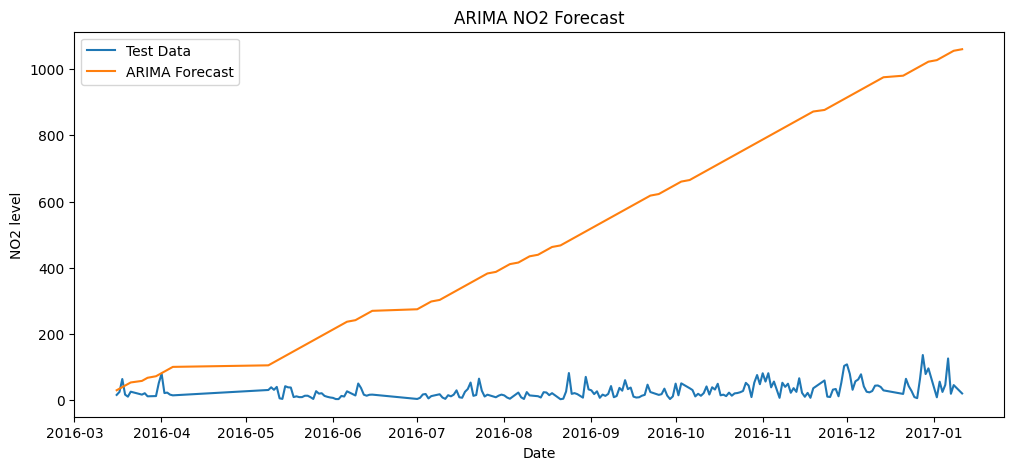

In [209]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_forecasts(test, predictions, title):

    plt.figure(figsize=(12,5))

    # actual
    sns.lineplot(x=test.index, y=test["no2_level"], label="Test Data")

    # forecast
    sns.lineplot(x=predictions.index, y=predictions["predicted_mean"],
                 label="ARIMA Forecast")

    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel("NO2 level")
    plt.show()

plot_forecasts(test, arima_predictions, "ARIMA NO2 Forecast")


In [210]:
def evaluate_model(test, predictions, model_name="Model"):

    y_true = test["no2_level"]
    y_pred = predictions["predicted_mean"]

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    print(f"{model_name} evaluation:")
    print(f"MAE  = {mae:.3f}")
    print(f"RMSE = {rmse:.3f}")
    print(f"MAPE = {mape:.2f}%")

    return {"MAE": mae, "RMSE": rmse, "MAPE": mape}

arima_metrics = evaluate_model(test, arima_predictions, "ARIMA")


ARIMA evaluation:
MAE  = 516.535
RMSE = 592.212
MAPE = 2780.68%


In [213]:
s: int = 5

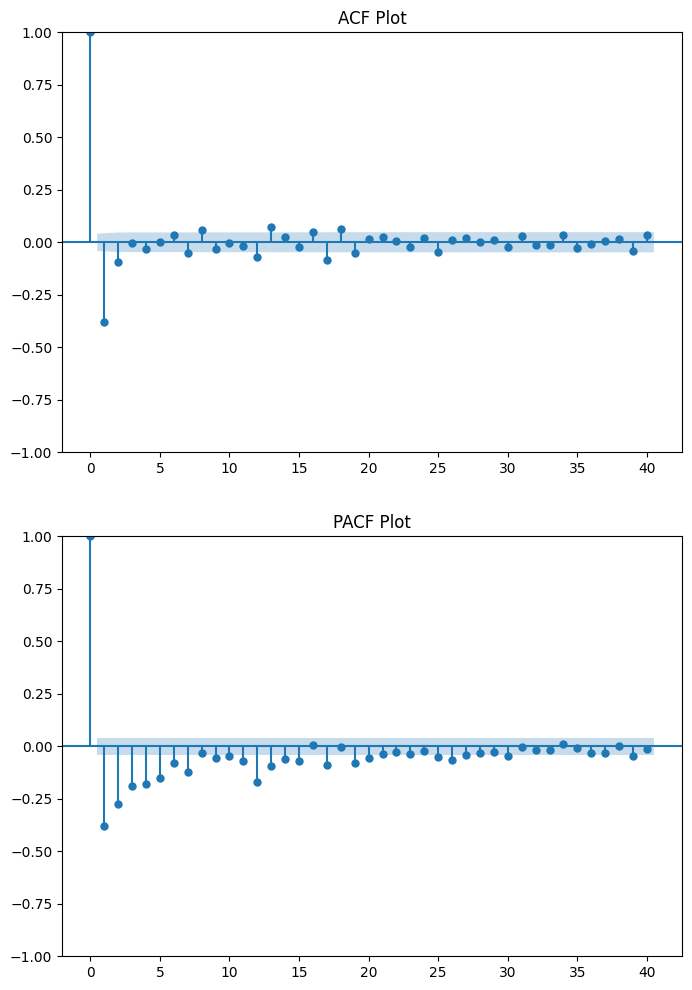

In [212]:
plot_acf_pacf()

In [215]:
P: int = 1
Q: int = 1
D: int = 1

In [216]:
train: pd.DataFrame
p: int
d: int
q: int
P: int
D: int
Q: int
s: int

# Define the SARIMA model
sarima_model: SARIMAX = SARIMAX(train['no2_level'],
                                order=(p, d, q),
                                seasonal_order=(P, D, Q, s))

# Fit the model
sarima_fit: SARIMAXResults = sarima_model.fit()

f:\Data Science & AI\London\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
f:\Data Science & AI\London\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [220]:
import pandas as pd
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
import seaborn as sns
import matplotlib.pyplot as plt

# ---- 1) Ensure time index and frequency ----
df = df.sort_index()
df = df.asfreq("D")     # change if your frequency is different

# ---- 2) Differencing to remove trend ----
df["no2_level_diff"] = df["no2_level"].diff()
df = df.dropna(subset=["no2_level_diff"])

# ---- 3) Train-test split ----
train_size = int(len(df) * 0.9)
train = df.iloc[:train_size]
test = df.iloc[train_size:]

print(len(train), len(test))

# ---- 4) Define SARIMA orders ----
# p, d, q = non-seasonal orders
# P, D, Q = seasonal orders
# s = seasonal period (e.g., 7 for weekly seasonality on daily data)

p, d, q = 1, 1, 1
P, D, Q, s = 1, 1, 1, 7   # <-- adjust this for your dataset

# ---- 5) Fit SARIMA on differenced series ----
sarima_model = SARIMAX(
    train["no2_level_diff"],
    order=(p, d, q),
    seasonal_order=(P, D, Q, s),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_fit = sarima_model.fit()

# ---- 6) Forecast differenced values ----
diff_forecast = sarima_fit.forecast(steps=len(test))

# ---- 7) Convert differenced predictions back to level ----
last_value = train["no2_level"].iloc[-1]
level_forecast = last_value + diff_forecast.cumsum()

# ---- 8) Build predictions DataFrame ----
sarima_predictions = pd.DataFrame(
    {"predicted_mean": level_forecast.values},
    index=test.index
)

sarima_predictions.head()


1899 212


f:\Data Science & AI\London\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
f:\Data Science & AI\London\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
f:\Data Science & AI\London\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
f:\Data Science & AI\London\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an

,predicted_mean
datetime,
2016-03-08 01:00:00,30.576662
2016-03-09 01:00:00,30.564004
2016-03-10 01:00:00,32.551640
2016-03-11 01:00:00,32.512016
2016-03-12 01:00:00,32.630851


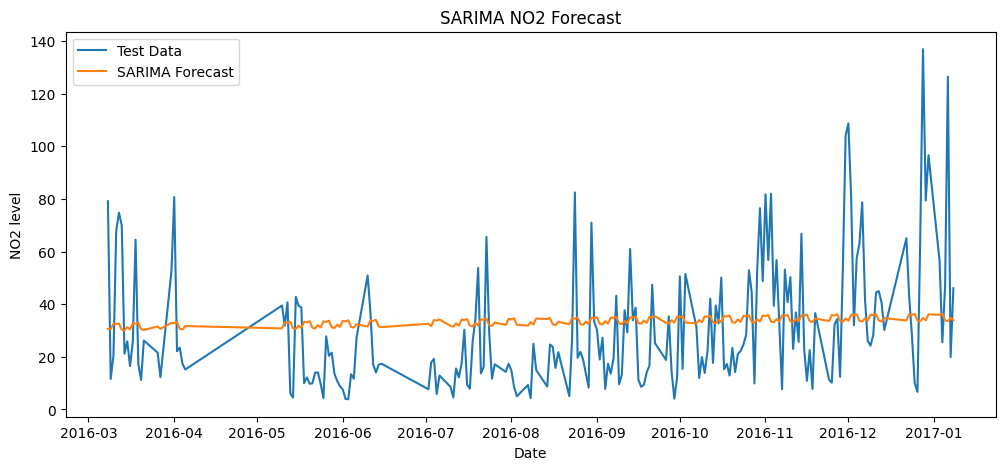

In [221]:
def plot_sarima_forecast(test, predictions, title):

    plt.figure(figsize=(12,5))

    sns.lineplot(x=test.index, y=test["no2_level"], label="Test Data")
    sns.lineplot(x=predictions.index, y=predictions["predicted_mean"],
                 label="SARIMA Forecast")

    plt.xlabel("Date")
    plt.ylabel("NO2 level")
    plt.title(title)
    plt.show()

plot_sarima_forecast(test, sarima_predictions, "SARIMA NO2 Forecast")


In [222]:
def evaluate_model(test, predictions, model_name="Model"):

    y_true = test["no2_level"]
    y_pred = predictions["predicted_mean"]

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    print(f"{model_name} evaluation:")
    print(f"MAE  = {mae:.3f}")
    print(f"RMSE = {rmse:.3f}")
    print(f"MAPE = {mape:.2f}%")

    return {"MAE": mae, "RMSE": rmse, "MAPE": mape}

sarima_metrics = evaluate_model(test, sarima_predictions, "SARIMA")


SARIMA evaluation:
MAE  = 18.941
RMSE = 23.683
MAPE = 117.99%


In [223]:
arima_metrics: dict[str, float]
sarima_metrics: dict[str, float]

evaluation_data: dict[str, list[str | float]] = {
    "Metric": ["MAE", "RMSE", "MAPE"],
    "ARIMA": [arima_metrics["MAE"], arima_metrics["RMSE"], f"{arima_metrics['MAPE'] * 100:.2f}%"],
    "SARIMA": [sarima_metrics["MAE"], sarima_metrics["RMSE"], f"{sarima_metrics['MAPE'] * 100:.2f}%"]
}

evaluation_df: pd.DataFrame = pd.DataFrame(evaluation_data)

evaluation_df

,Metric,ARIMA,SARIMA
0,MAE,516.535455,18.940765
1,RMSE,592.212457,23.682636
2,MAPE,278068.47%,11798.88%


In [229]:
import pandas as pd
import numpy as np
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

# -----------------------------
# 1) Keep only required columns
# -----------------------------
df = df[['datetime', 'no2_level']].copy()

# -----------------------------
# 2) Convert to proper datetime
# -----------------------------
df['datetime'] = pd.to_datetime(df['datetime'], errors='coerce')
df = df.dropna(subset=['datetime', 'no2_level'])

# -----------------------------
# 3) Sort chronologically
# -----------------------------
df = df.sort_values('datetime')

# -----------------------------
# 4) Rename to Prophet format
# -----------------------------
df = df.rename(columns={'datetime': 'ds', 'no2_level': 'y'})

# -----------------------------
# 5) Train–test split (90/10)
# -----------------------------
split_index = int(len(df) * 0.9)
train_df = df.iloc[:split_index].copy()
test_df = df.iloc[split_index:].copy()

print("Train size:", len(train_df))
print("Test size:", len(test_df))

# -----------------------------
# 6) Fit Prophet
# -----------------------------
# 7) Fit Prophet
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=True
)
model.fit(train_df)

# 8) Create FUTURE dataframe with HOURLY frequency
future = model.make_future_dataframe(
    periods=len(test_df),
    freq='H'
)

# 9) Forecast
forecast = model.predict(future)

# 10) Align forecast with test period SAFELY
forecast_test = forecast.set_index('ds').loc[test_df['ds']]

test_df = test_df.set_index('ds')

# -----------------------------
# 10) Evaluation
# -----------------------------
y_true = test_df['y']
y_pred = forecast_test['yhat']

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

print("Prophet performance:")
print(f" MAE  = {mae:.3f}")
print(f" RMSE = {rmse:.3f}")
print(f" MAPE = {mape:.2f}%")


Train size: 516343
Test size: 57372


12:51:52 - cmdstanpy - INFO - Chain [1] start processing
12:54:49 - cmdstanpy - INFO - Chain [1] done processing
f:\Data Science & AI\London\venv\Lib\site-packages\prophet\forecaster.py:1872: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  dates = pd.date_range(


Prophet performance:
 MAE  = 17.168
 RMSE = 21.576
 MAPE = inf%


In [231]:
Camden_Bloomsbury_no2

datetime
2010-01-31    84.8
2010-02-01    84.8
2010-02-02    84.8
2010-02-03    84.8
2010-02-04    84.8
              ... 
2023-07-27    27.7
2023-07-28    27.7
2023-07-29    27.7
2023-07-30    27.7
2023-07-31     5.3
Freq: D, Name: no2_level, Length: 4930, dtype: float64

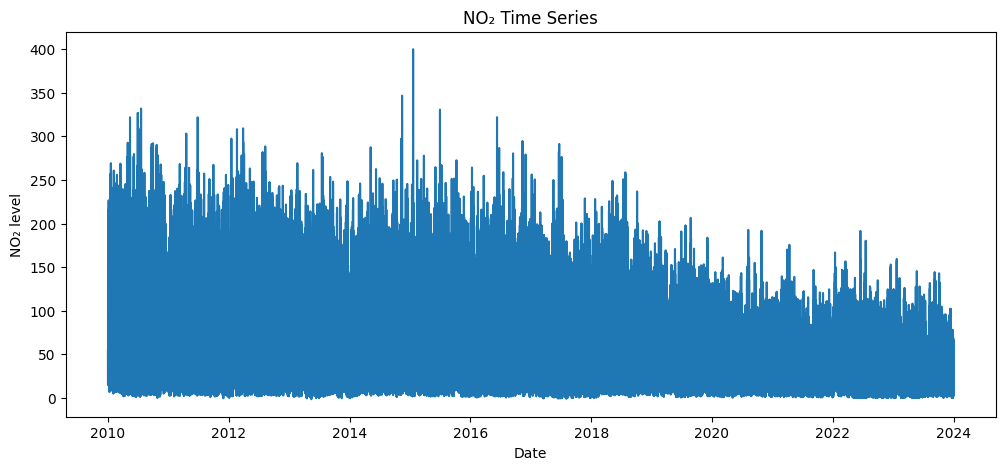

In [238]:
plt.figure(figsize=(12,5))
plt.plot(df['ds'], df['y'])
plt.title("NO₂ Time Series")
plt.xlabel("Date")
plt.ylabel("NO₂ level")
plt.show()


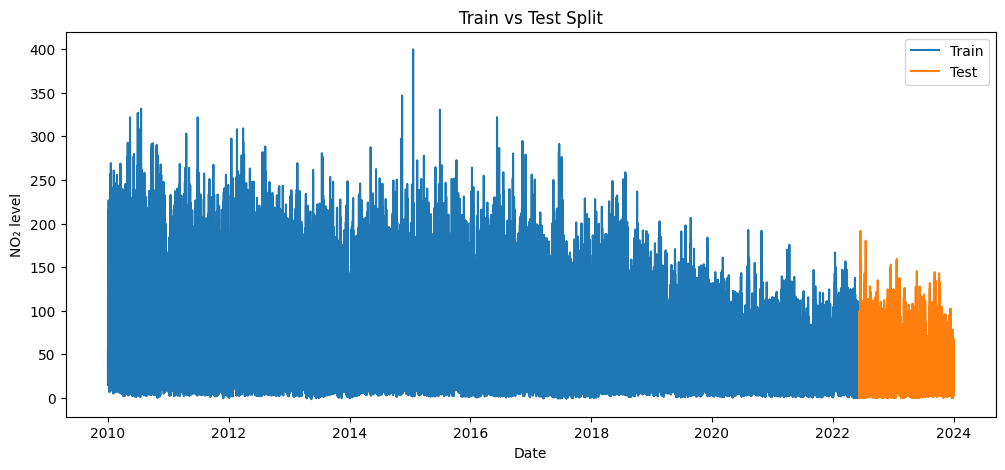

In [239]:
plt.figure(figsize=(12,5))
plt.plot(train_df['ds'], train_df['y'], label="Train")
plt.plot(test_df.index, test_df['y'], label="Test")
plt.title("Train vs Test Split")
plt.xlabel("Date")
plt.ylabel("NO₂ level")
plt.legend()
plt.show()


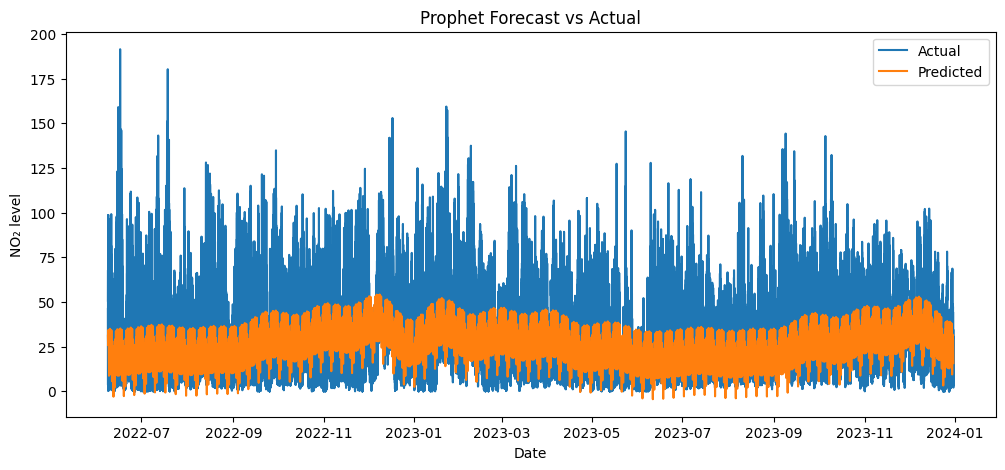

In [240]:
plt.figure(figsize=(12,5))
plt.plot(test_df.index, y_true, label="Actual")
plt.plot(forecast_test.index, y_pred, label="Predicted")
plt.title("Prophet Forecast vs Actual")
plt.xlabel("Date")
plt.ylabel("NO₂ level")
plt.legend()
plt.show()
